In [14]:
# Install required packages into the current Jupyter kernel environment
# Using %pip ensures installation happens in the same interpreter the notebook is using
%pip install -q pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [15]:
# Import pandas for data handling
import pandas as pd

# Configure pandas display so all columns are visible during inspection
pd.set_option("display.max_columns", None)

# First attempt: load with semicolon separator (common in some bank marketing CSV versions)
df = pd.read_csv("bank.csv", sep=";")

# If only one column appears, the separator is likely wrong for this file
if df.shape[1] == 1:
    # Reload using comma separator (your current file uses comma-separated values)
    df = pd.read_csv("bank.csv", sep=",")

# Print number of rows and columns to understand dataset size and parsing success
print("Dataset shape (rows, columns):", df.shape)

# Print all column names to verify features loaded correctly
print("\nColumns:")
print(df.columns.tolist())

# Show first 5 rows to inspect structure and sample values
print("\nFirst 5 rows:")
print(df.head())

# Show data types and non-null counts to understand preprocessing needs
print("\nDataFrame info:")
print(df.info())

# Count missing values in each column (if any)
print("\nMissing values per column:")
print(df.isnull().sum())

# Detect the target column name used by this dataset version
if "y" in df.columns:
    # UCI-style naming
    target_col = "y"
elif "deposit" in df.columns:
    # Kaggle variant naming
    target_col = "deposit"
else:
    # Raise a clear error if neither expected target exists
    raise ValueError("Target column not found. Expected 'y' or 'deposit'.")

# Display which target column was selected for transparency
print(f"\nUsing target column: {target_col}")

# Check target distribution in counts
print("\nTarget distribution (counts):")
print(df[target_col].value_counts())

# Check target distribution in percentage terms
print("\nTarget distribution (percent):")
print(df[target_col].value_counts(normalize=True) * 100)

Dataset shape (rows, columns): (11162, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

First 5 rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     

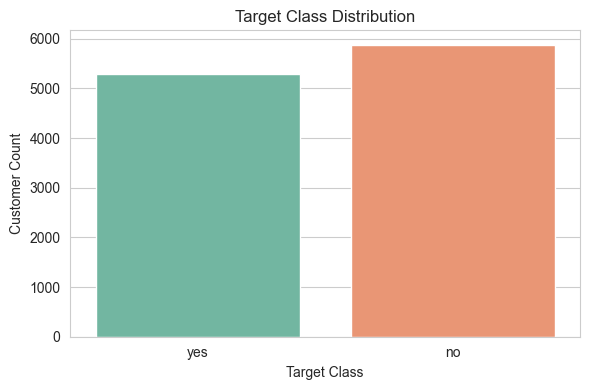

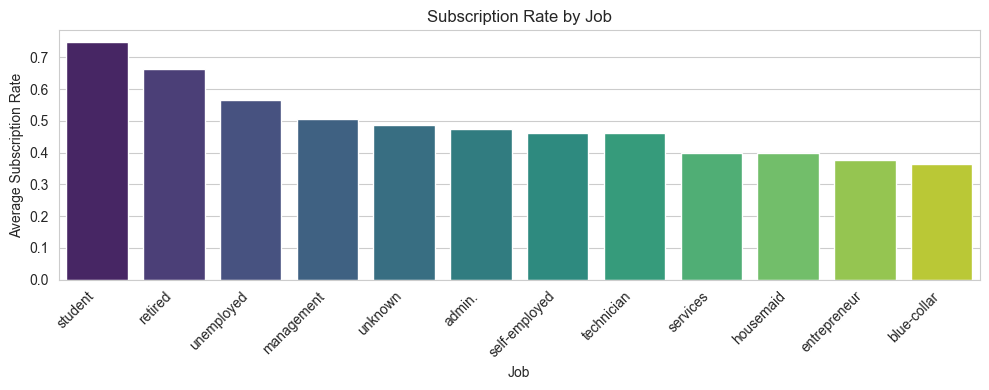

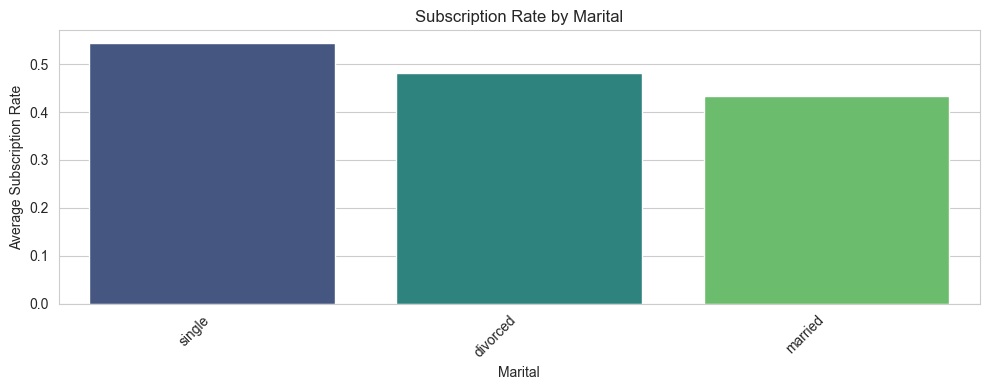

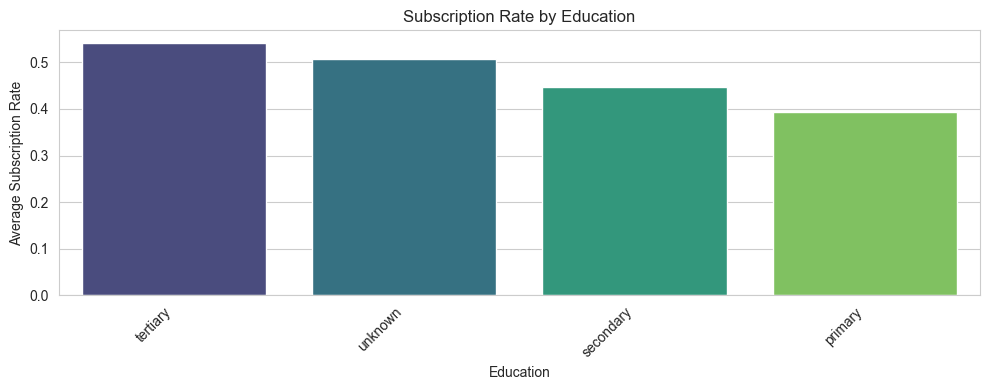

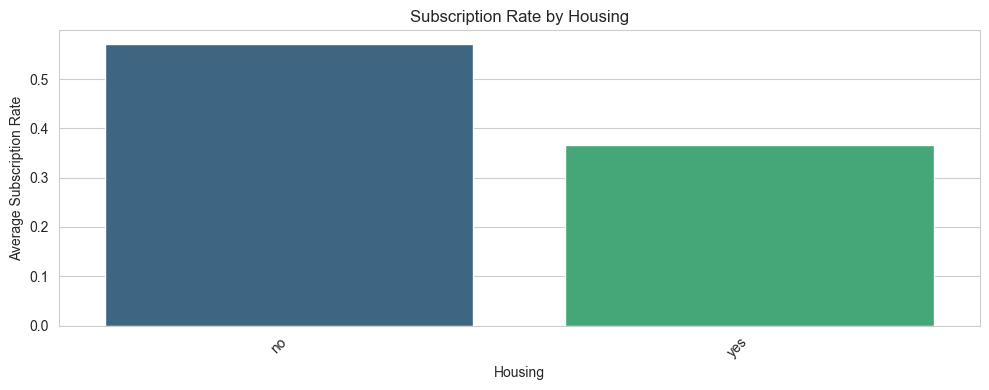

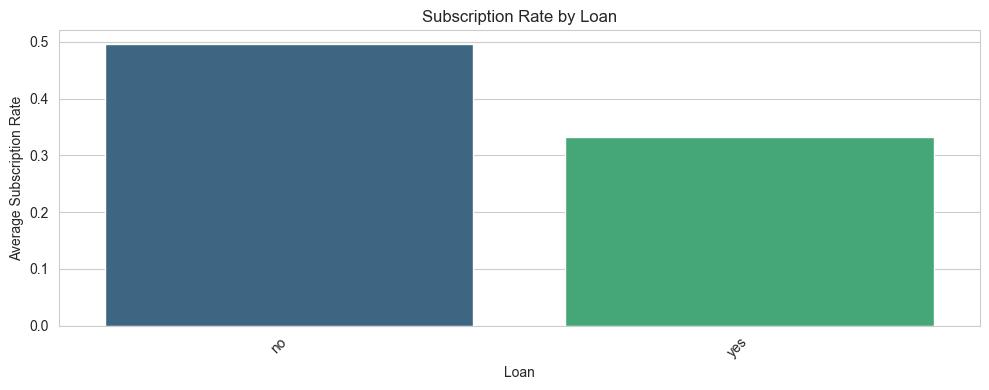

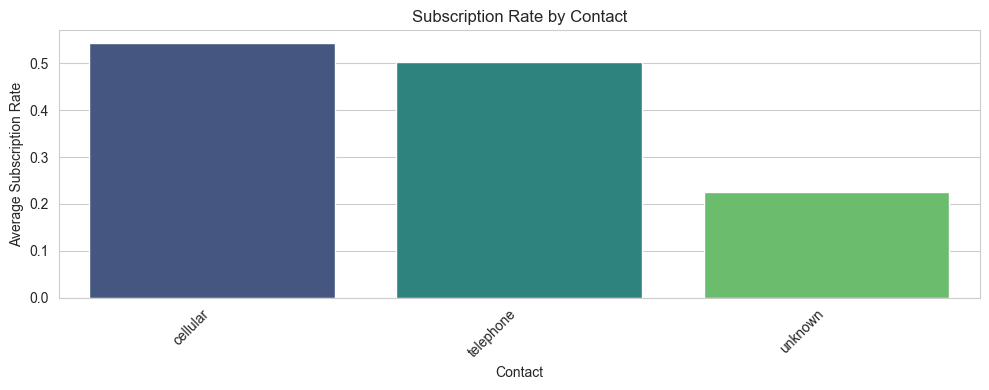

/var/folders/m5/f3mx1smj2t36zgx2q5f7bgkh0000gn/T/ipykernel_95912/1674113342.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x=target_col, y=col, ax=axes[1], palette="Set3")


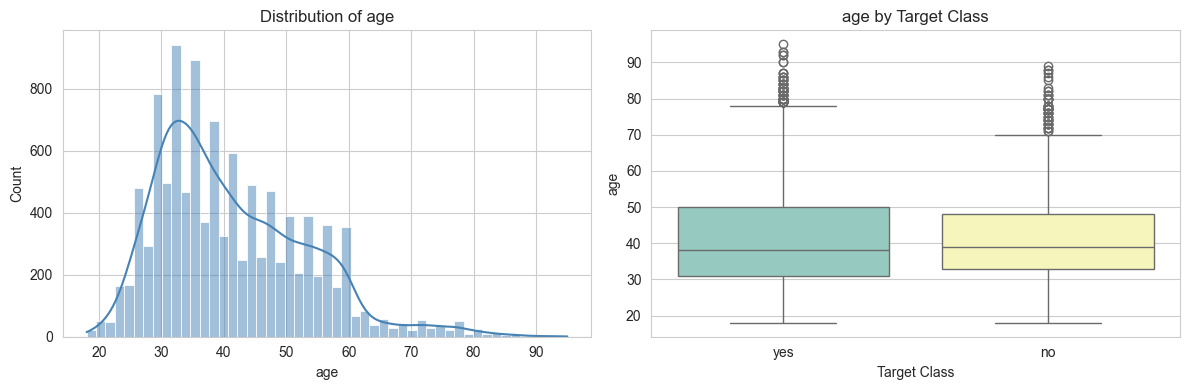

/var/folders/m5/f3mx1smj2t36zgx2q5f7bgkh0000gn/T/ipykernel_95912/1674113342.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x=target_col, y=col, ax=axes[1], palette="Set3")


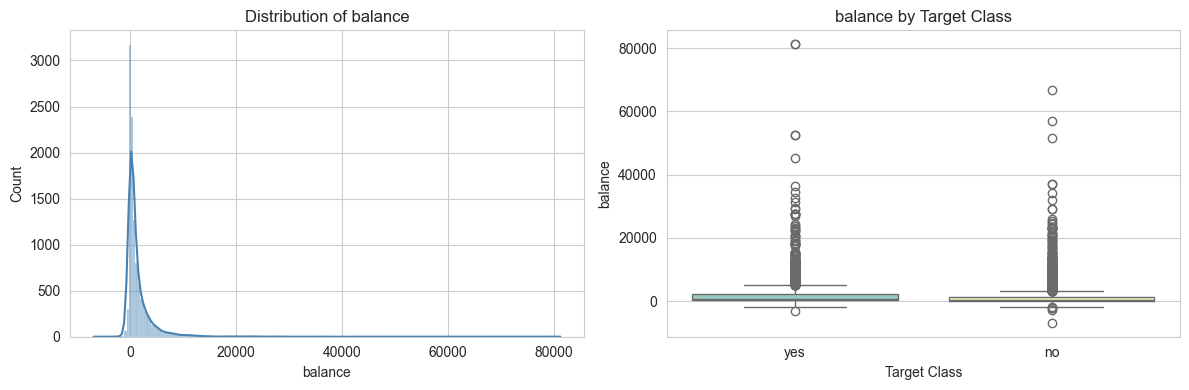

/var/folders/m5/f3mx1smj2t36zgx2q5f7bgkh0000gn/T/ipykernel_95912/1674113342.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x=target_col, y=col, ax=axes[1], palette="Set3")


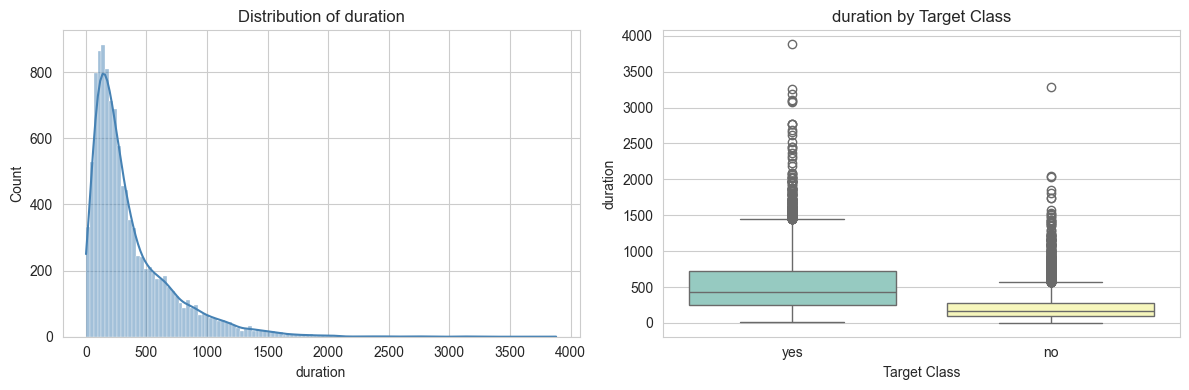

/var/folders/m5/f3mx1smj2t36zgx2q5f7bgkh0000gn/T/ipykernel_95912/1674113342.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x=target_col, y=col, ax=axes[1], palette="Set3")


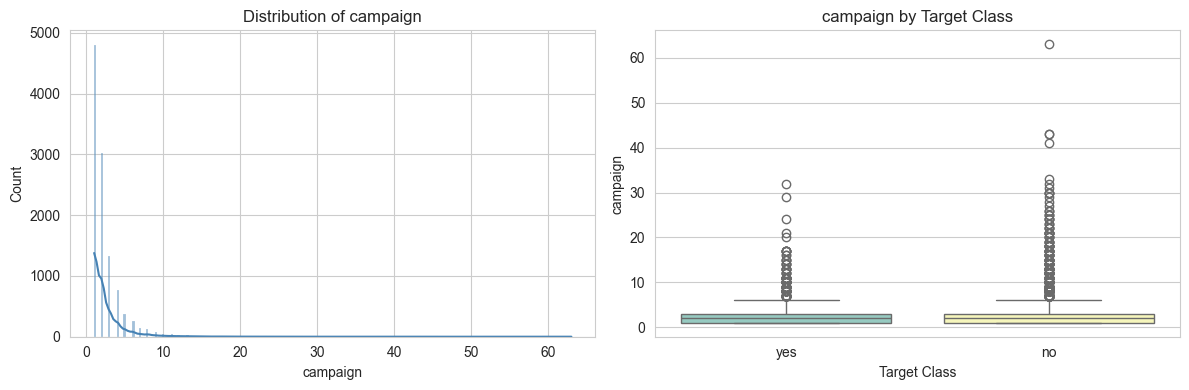

/var/folders/m5/f3mx1smj2t36zgx2q5f7bgkh0000gn/T/ipykernel_95912/1674113342.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x=target_col, y=col, ax=axes[1], palette="Set3")


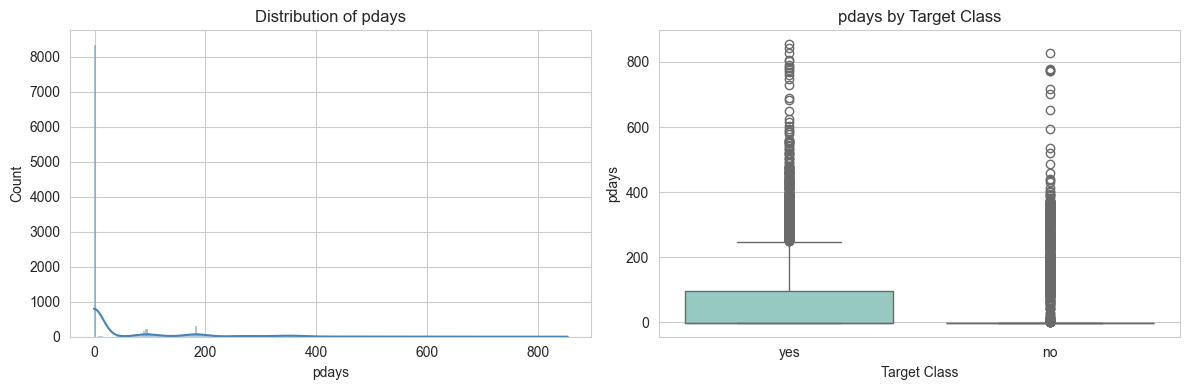

/var/folders/m5/f3mx1smj2t36zgx2q5f7bgkh0000gn/T/ipykernel_95912/1674113342.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x=target_col, y=col, ax=axes[1], palette="Set3")


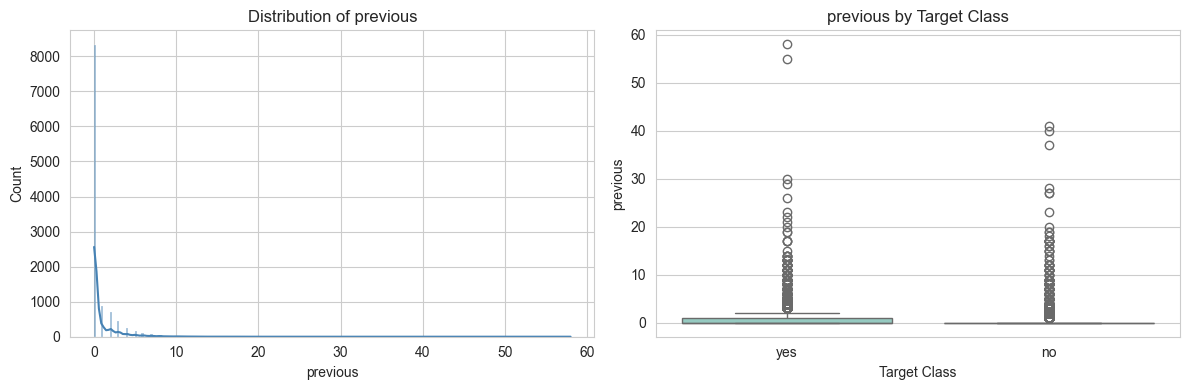

EDA complete. Focus on categories with higher subscription rate for campaign targeting.
For Bahrain banking use cases, these patterns help prioritize segments for product cross-sell.


In [16]:
# Import plotting libraries for visual exploratory data analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plotting style for clearer visuals
sns.set_style("whitegrid")

# Standardize target values to 1/0 for easier analysis
# Convert to string first so this works with both object dtype and pandas string dtype
target_clean = df[target_col].astype(str).str.strip().str.lower()

# Map yes/no labels to numeric values used for rates and model-ready summaries
target_numeric = target_clean.map({"yes": 1, "no": 0})

# If labels are already numeric (for some dataset variants), coerce directly
if target_numeric.isnull().all():
    target_numeric = pd.to_numeric(df[target_col], errors="coerce")

# Basic quality check: confirm conversion succeeded
if target_numeric.isnull().any():
    bad_values = sorted(df.loc[target_numeric.isnull(), target_col].astype(str).unique())
    raise ValueError(f"Unexpected target values found: {bad_values}")

# Ensure numeric dtype so groupby mean always works
target_numeric = target_numeric.astype(float)

# Create a copy of the DataFrame to avoid modifying original data accidentally
eda_df = df.copy()

# Add numeric target column for aggregation and plotting
eda_df["target_numeric"] = target_numeric

# Plot 1: class distribution (important for model evaluation strategy)
plt.figure(figsize=(6, 4))
# Draw count plot for original target labels
sns.countplot(data=eda_df, x=target_col, hue=target_col, palette="Set2", legend=False)
# Add chart title to explain purpose
plt.title("Target Class Distribution")
# Label x-axis for clarity
plt.xlabel("Target Class")
# Label y-axis for clarity
plt.ylabel("Customer Count")
# Improve spacing so labels fit cleanly
plt.tight_layout()
# Render chart
plt.show()

# Select key categorical columns commonly useful in retail banking marketing analysis
categorical_cols = ["job", "marital", "education", "housing", "loan", "contact"]

# Keep only columns that actually exist in this dataset version
categorical_cols = [col for col in categorical_cols if col in eda_df.columns]

# For each categorical feature, plot average subscription rate by category
for col in categorical_cols:
    # Compute mean of target_numeric by category (gives conversion probability)
    rate_df = (
        eda_df.groupby(col, as_index=False)["target_numeric"]
        .mean()
        .sort_values("target_numeric", ascending=False)
    )

    # Create figure for this feature
    plt.figure(figsize=(10, 4))
    # Draw bar chart of conversion rates
    sns.barplot(data=rate_df, x=col, y="target_numeric", hue=col, palette="viridis", legend=False)
    # Rotate x labels if categories are long
    plt.xticks(rotation=45, ha="right")
    # Add title with business meaning
    plt.title(f"Subscription Rate by {col.title()}")
    # Label y axis as probability-like rate
    plt.ylabel("Average Subscription Rate")
    # Label x axis as feature name
    plt.xlabel(col.title())
    # Keep spacing neat
    plt.tight_layout()
    # Show chart
    plt.show()

# Select important numeric columns for distribution analysis
numeric_cols = ["age", "balance", "duration", "campaign", "pdays", "previous"]

# Keep only numeric columns that exist in this dataset version
numeric_cols = [col for col in numeric_cols if col in eda_df.columns]

# Plot distributions for numeric features to detect skew/outliers
for col in numeric_cols:
    # Create figure with two side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: histogram + density curve for overall distribution
    sns.histplot(eda_df[col], kde=True, ax=axes[0], color="steelblue")
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    # Right: boxplot split by target to compare positive vs negative responders
    sns.boxplot(data=eda_df, x=target_col, y=col, ax=axes[1], palette="Set3")
    axes[1].set_title(f"{col} by Target Class")
    axes[1].set_xlabel("Target Class")
    axes[1].set_ylabel(col)

    # Adjust spacing between subplots
    plt.tight_layout()
    # Display plots
    plt.show()

# Print quick interpretation guide for business context
print("EDA complete. Focus on categories with higher subscription rate for campaign targeting.")
print("For Bahrain banking use cases, these patterns help prioritize segments for product cross-sell.")

In [17]:
# Step 3 — Prepare data for Level 1 ML (features, train/test split, preprocessing)
# Trees (Random Forest, Gradient Boosting) do not need scaling, but we still use
# a ColumnTransformer so categorical columns are encoded consistently for sklearn.

# Import train/test splitter so positive/negative classes stay balanced in both sets
from sklearn.model_selection import train_test_split

# Import column transformer and encoders to build one preprocessing pipeline
from sklearn.compose import ColumnTransformer

# Import one-hot encoder for categorical banking attributes (job, education, etc.)
from sklearn.preprocessing import OneHotEncoder

# Import pipeline to chain preprocessing with a model later (same pattern banks use in MLOps)
from sklearn.pipeline import Pipeline

# Import tree models we will plug in after preprocessing is validated
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Build list of feature columns: all columns except the target we predict
feature_cols = [col for col in df.columns if col != target_col]

# Remove call-duration feature to reduce target leakage (duration is known after the interaction)
# In real outbound campaigns you predict *before* the call, so duration should not drive the model
leakage_cols = ["duration"]
feature_cols = [col for col in feature_cols if col not in leakage_cols]

# Build feature matrix X and label vector y from the cleaned dataframe
X = df[feature_cols].copy()

# Convert deposit yes/no to binary integers for sklearn classifiers
y = df[target_col].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})

# Split data: 80% train, 20% test, stratified so "yes" share is similar in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Print split sizes so we confirm enough rows for stable metrics
print("Train rows:", X_train.shape[0], "Test rows:", X_test.shape[0])

# Identify numeric columns automatically (int/float) for the transformer
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()

# Identify non-numeric columns (strings/categories) for one-hot encoding
categorical_features = [col for col in X_train.columns if col not in numeric_features]

# Configure one-hot encoder: ignore unknown categories at prediction time (robust to new labels)
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Combine numeric passthrough and categorical encoding in one preprocessing object
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
)

# Fit preprocessor on training data only (prevents information leaking from test into encodings)
preprocessor.fit(X_train)

# Show how many columns exist after encoding (helps you explain model input dimension in interviews)
encoded_feature_count = preprocessor.transform(X_train).shape[1]
print("Raw feature columns used:", len(feature_cols))
print("Encoded matrix columns after preprocessing:", encoded_feature_count)

# Example pipelines: same preprocessing, different tree models (Level 1 comparison story)
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(random_state=42, class_weight="balanced")),
    ]
)

gb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42)),
    ]
)

# Note: class_weight on RF helps with slight imbalance; GB has no class_weight in sklearn,
# so we may tune scale_pos_weight-style approaches later if needed.

print("Preprocessing + model pipelines are ready. Next cell: fit, predict, and evaluate.")

Train rows: 8929 Test rows: 2233
Raw feature columns used: 15
Encoded matrix columns after preprocessing: 50
Preprocessing + model pipelines are ready. Next cell: fit, predict, and evaluate.


Threshold comparison (Gradient Boosting):
   threshold  precision  recall      f1
0       0.30     0.5852  0.8866  0.7050
1       0.35     0.6360  0.8110  0.7129
2       0.40     0.7021  0.7372  0.7192
3       0.45     0.7567  0.6701  0.7108
4       0.50     0.7990  0.6049  0.6885
5       0.55     0.8250  0.5435  0.6553
6       0.60     0.8481  0.4962  0.6261
7       0.65     0.8574  0.4490  0.5893
8       0.70     0.8574  0.3979  0.5436

Best threshold by F1:
threshold    0.4000
precision    0.7021
recall       0.7372
f1           0.7192
Name: 2, dtype: float64

Business recommendation (precision >= 0.65, max recall):
threshold    0.4000
precision    0.7021
recall       0.7372
f1           0.7192
Name: 2, dtype: float64


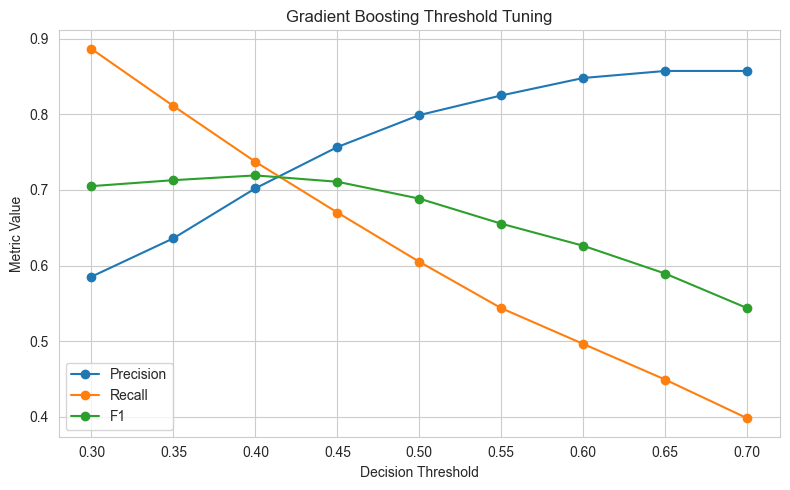

Use the chosen threshold as a business policy setting, not a model quality score.
In Bahrain banking campaigns, this helps balance conversion growth vs outreach cost.


In [18]:
# Step 5 — Threshold tuning for campaign decision-making
# We use Gradient Boosting probabilities because it had higher ROC-AUC in Step 4.

# Import numpy for creating a threshold grid
import numpy as np

# Import pandas for tabular threshold comparison output
import pandas as pd

# Import metrics used to evaluate threshold trade-offs
from sklearn.metrics import precision_score, recall_score, f1_score

# Create a list of thresholds from 0.30 to 0.70 (inclusive) with step 0.05
thresholds = np.arange(0.30, 0.71, 0.05)

# Prepare an empty list to store metrics for each threshold
threshold_results = []

# Loop over each threshold value and calculate classification metrics
for t in thresholds:
    # Convert probabilities to class labels using the current threshold
    y_pred_t = (gb_proba >= t).astype(int)

    # Compute precision: among predicted yes, how many were truly yes
    precision_t = precision_score(y_test, y_pred_t, zero_division=0)

    # Compute recall: among true yes customers, how many we captured
    recall_t = recall_score(y_test, y_pred_t, zero_division=0)

    # Compute F1: harmonic balance of precision and recall
    f1_t = f1_score(y_test, y_pred_t, zero_division=0)

    # Append current threshold metrics as one row of results
    threshold_results.append(
        {
            "threshold": round(float(t), 2),
            "precision": round(float(precision_t), 4),
            "recall": round(float(recall_t), 4),
            "f1": round(float(f1_t), 4),
        }
    )

# Convert list of metric rows into a DataFrame for clear display
threshold_df = pd.DataFrame(threshold_results)

# Print the complete threshold comparison table
print("Threshold comparison (Gradient Boosting):")
print(threshold_df)

# Find threshold that gives the best F1 score (balanced operating point)
best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]

# Print best-F1 threshold recommendation
print("\nBest threshold by F1:")
print(best_f1_row)

# Example business rule: maximize recall while keeping precision at least 0.65
# This is useful when bank wants to capture more likely subscribers but avoid too many low-quality leads.
candidate_rows = threshold_df[threshold_df["precision"] >= 0.65]

# If any threshold satisfies the precision floor, pick the one with highest recall
if not candidate_rows.empty:
    recommended_row = candidate_rows.sort_values("recall", ascending=False).iloc[0]
    print("\nBusiness recommendation (precision >= 0.65, max recall):")
    print(recommended_row)
else:
    # If no threshold reaches precision floor, provide fallback message
    print("\nNo threshold met precision >= 0.65 in this range. Consider adjusting threshold range or model tuning.")

# Plot threshold vs precision/recall/f1 to visualize trade-offs clearly
import matplotlib.pyplot as plt

# Create a figure for threshold metric curves
plt.figure(figsize=(8, 5))

# Draw precision curve across thresholds
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")

# Draw recall curve across thresholds
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")

# Draw F1 curve across thresholds
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")

# Add plot title for context
plt.title("Gradient Boosting Threshold Tuning")

# Label x-axis
plt.xlabel("Decision Threshold")

# Label y-axis
plt.ylabel("Metric Value")

# Add legend so lines are identifiable
plt.legend()

# Add grid for easier reading
plt.grid(True)

# Improve spacing
plt.tight_layout()

# Show plot
plt.show()

# Print interpretation note for portfolio storytelling
print("Use the chosen threshold as a business policy setting, not a model quality score.")
print("In Bahrain banking campaigns, this helps balance conversion growth vs outreach cost.")

Random Forest ROC-AUC: 0.775
Gradient Boosting ROC-AUC: 0.7935

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.81      0.75      1175
           1       0.75      0.62      0.68      1058

    accuracy                           0.72      2233
   macro avg       0.73      0.72      0.72      2233
weighted avg       0.73      0.72      0.72      2233


Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.86      0.78      1175
           1       0.80      0.60      0.69      1058

    accuracy                           0.74      2233
   macro avg       0.75      0.73      0.73      2233
weighted avg       0.75      0.74      0.74      2233



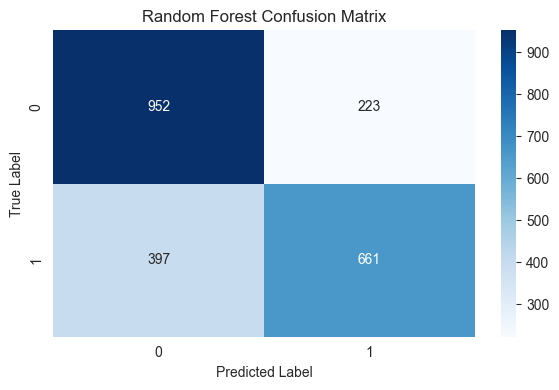

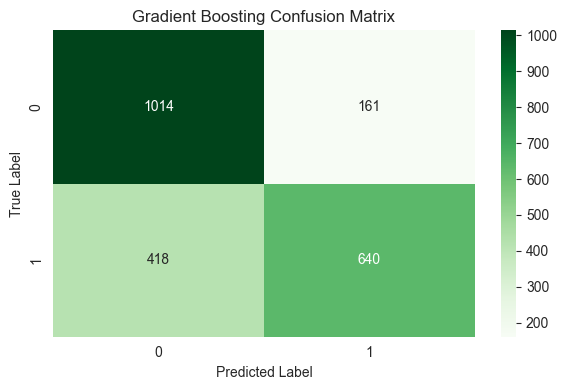

<Figure size 700x500 with 0 Axes>

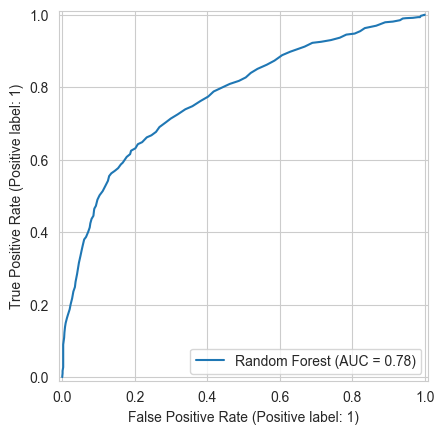

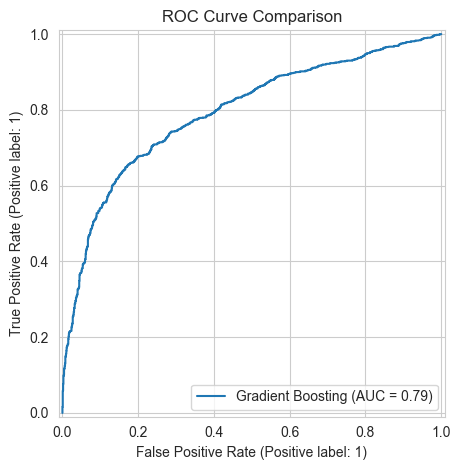

Use ROC-AUC + precision/recall tradeoff to pick a model for campaign objectives.


In [20]:
# Step 4 — Train and evaluate Random Forest vs Gradient Boosting

# Import evaluation metrics for classification quality
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
)

# Import plotting tools for metric visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Fit Random Forest pipeline on training data
rf_pipeline.fit(X_train, y_train)

# Fit Gradient Boosting pipeline on training data
gb_pipeline.fit(X_train, y_train)

# Predict class labels on test data for Random Forest
rf_pred = rf_pipeline.predict(X_test)

# Predict class probabilities on test data for Random Forest
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

# Predict class labels on test data for Gradient Boosting
gb_pred = gb_pipeline.predict(X_test)

# Predict class probabilities on test data for Gradient Boosting
gb_proba = gb_pipeline.predict_proba(X_test)[:, 1]

# Compute ROC-AUC scores for both models
rf_auc = roc_auc_score(y_test, rf_proba)
gb_auc = roc_auc_score(y_test, gb_proba)

# Print ROC-AUC comparison
print("Random Forest ROC-AUC:", round(rf_auc, 4))
print("Gradient Boosting ROC-AUC:", round(gb_auc, 4))

# Print detailed classification metrics for Random Forest
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

# Print detailed classification metrics for Gradient Boosting
print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, gb_pred))

# Build confusion matrices for both models
rf_cm = confusion_matrix(y_test, rf_pred)
gb_cm = confusion_matrix(y_test, gb_pred)

# Plot confusion matrix for Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Plot confusion matrix for Gradient Boosting
plt.figure(figsize=(6, 4))
sns.heatmap(gb_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Plot ROC curves for both models on the same figure
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, gb_proba, name="Gradient Boosting")
plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

# Print quick guidance for model selection
print("Use ROC-AUC + precision/recall tradeoff to pick a model for campaign objectives.")

Threshold comparison (Gradient Boosting):
   threshold  precision  recall      f1
0       0.30     0.5852  0.8866  0.7050
1       0.35     0.6360  0.8110  0.7129
2       0.40     0.7021  0.7372  0.7192
3       0.45     0.7567  0.6701  0.7108
4       0.50     0.7990  0.6049  0.6885
5       0.55     0.8250  0.5435  0.6553
6       0.60     0.8481  0.4962  0.6261
7       0.65     0.8574  0.4490  0.5893
8       0.70     0.8574  0.3979  0.5436

Best threshold by F1:
threshold    0.4000
precision    0.7021
recall       0.7372
f1           0.7192
Name: 2, dtype: float64

Business recommendation (precision >= 0.65, highest recall):
threshold    0.4000
precision    0.7021
recall       0.7372
f1           0.7192
Name: 2, dtype: float64


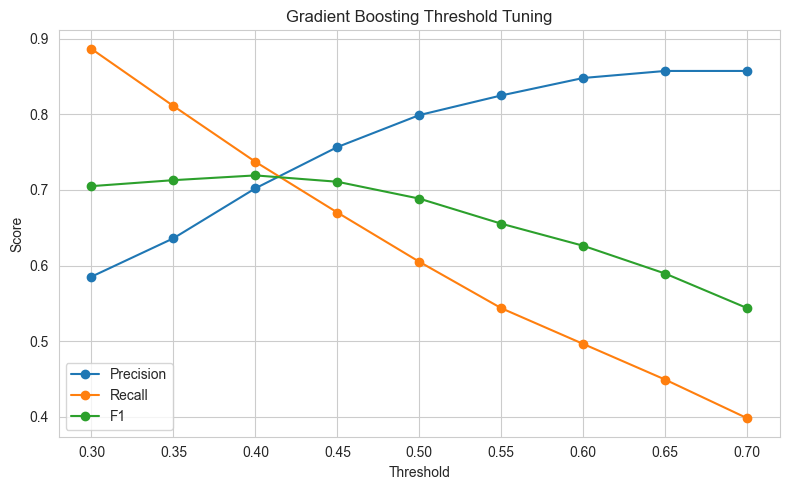

Choose threshold based on business objective (cost control vs response capture).


In [21]:
# Step 5 — Threshold tuning for campaign decision-making
# This step helps convert model probabilities into a practical calling policy.

# Import numpy for creating threshold ranges
import numpy as np

# Import pandas for tabular display
import pandas as pd

# Import evaluation metrics for threshold analysis
from sklearn.metrics import precision_score, recall_score, f1_score

# Safety check: confirm Step 4 variables are available
if "gb_proba" not in globals() or "y_test" not in globals():
    raise ValueError("Run Step 4 first so gb_proba and y_test are available.")

# Create threshold values from 0.30 to 0.70
thresholds = np.arange(0.30, 0.71, 0.05)

# Store metric results for each threshold
results = []

# Evaluate each threshold
for t in thresholds:
    # Convert probabilities to predicted class labels at this threshold
    y_pred_t = (gb_proba >= t).astype(int)

    # Calculate precision (quality of selected customers)
    p = precision_score(y_test, y_pred_t, zero_division=0)

    # Calculate recall (coverage of true responders)
    r = recall_score(y_test, y_pred_t, zero_division=0)

    # Calculate F1 score (balance of precision and recall)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    # Save row
    results.append({
        "threshold": round(float(t), 2),
        "precision": round(float(p), 4),
        "recall": round(float(r), 4),
        "f1": round(float(f1), 4),
    })

# Convert to DataFrame for easier interpretation
threshold_df = pd.DataFrame(results)

# Show all threshold results
print("Threshold comparison (Gradient Boosting):")
print(threshold_df)

# Best balanced threshold by F1
best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print("\nBest threshold by F1:")
print(best_f1_row)

# Example business rule: prioritize recall while maintaining precision >= 0.65
candidate_rows = threshold_df[threshold_df["precision"] >= 0.65]
if not candidate_rows.empty:
    recommended_row = candidate_rows.sort_values("recall", ascending=False).iloc[0]
    print("\nBusiness recommendation (precision >= 0.65, highest recall):")
    print(recommended_row)
else:
    print("\nNo threshold in this range reached precision >= 0.65.")

# Plot metric trade-offs across thresholds
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.title("Gradient Boosting Threshold Tuning")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Choose threshold based on business objective (cost control vs response capture).")

Top-N targeting simulation (Gradient Boosting):
   top_percent  customers_targeted  response_rate_in_target  \
0           10                 224                   0.9196   
1           20                 447                   0.8747   
2           30                 670                   0.8343   
3           40                 894                   0.7729   
4           50                1117                   0.7010   

   baseline_response_rate  lift_vs_random  responders_captured  capture_rate  
0                  0.4738           1.941                  206        0.1947  
1                  0.4738           1.846                  391        0.3696  
2                  0.4738           1.761                  559        0.5284  
3                  0.4738           1.631                  691        0.6531  
4                  0.4738           1.479                  783        0.7401  


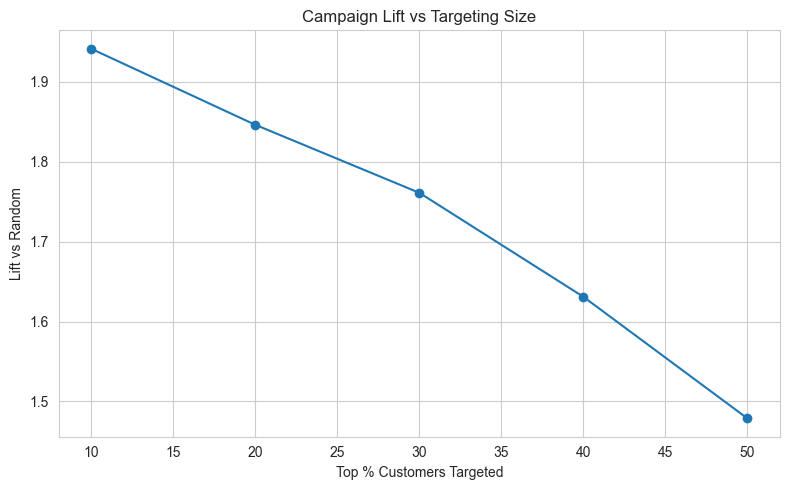

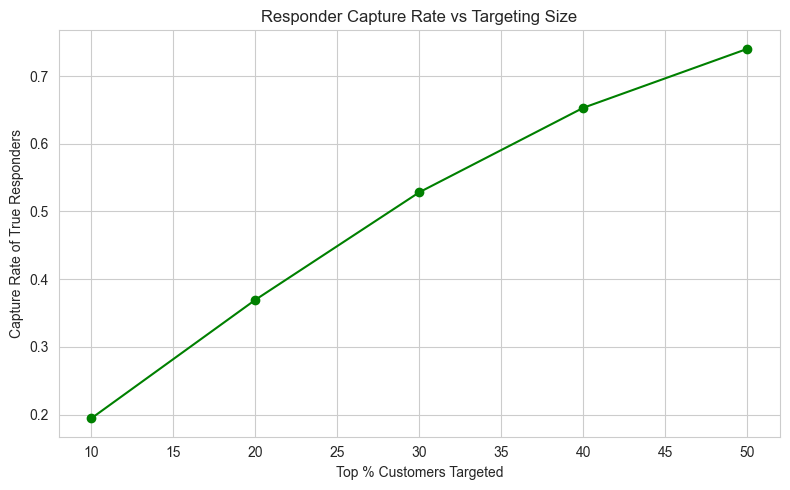

Best lift scenario:
top_percent                 10.0000
customers_targeted         224.0000
response_rate_in_target      0.9196
baseline_response_rate       0.4738
lift_vs_random               1.9410
responders_captured        206.0000
capture_rate                 0.1947
Name: 0, dtype: float64

Interpretation:
Higher lift means better targeting efficiency than random outreach.
Use this table to choose campaign size based on budget and conversion goals.


In [23]:
# Step 6 — Top-N targeting simulation (campaign lift analysis)
# This simulates how many likely subscribers we capture when targeting only top-scored customers.

# Import numpy for numeric operations
import numpy as np

# Import pandas for tabular analysis
import pandas as pd

# Import matplotlib for plotting campaign lift visuals
import matplotlib.pyplot as plt

# Safety check: ensure probabilities from Step 4 exist
if "gb_proba" not in globals() or "y_test" not in globals():
    raise ValueError("Run Step 4 first so gb_proba and y_test are available.")

# Build evaluation table with true labels and model scores
# true_label: actual outcome (1=yes, 0=no)
# score: predicted probability from Gradient Boosting model
eval_df = pd.DataFrame({
    "true_label": y_test.values,
    "score": gb_proba,
})

# Sort customers by predicted score descending (highest propensity first)
eval_df = eval_df.sort_values("score", ascending=False).reset_index(drop=True)

# Calculate overall baseline response rate (what random targeting would get)
baseline_rate = eval_df["true_label"].mean()

# Define campaign coverage levels to simulate (top 10%, 20%, 30%, 40%, 50%)
coverage_levels = [0.10, 0.20, 0.30, 0.40, 0.50]

# Prepare results list for each top-N strategy
lift_results = []

# Evaluate each coverage level
for cov in coverage_levels:
    # Determine number of customers included in top-N slice
    n_customers = int(np.ceil(len(eval_df) * cov))

    # Select top-scored customers for this campaign size
    top_slice = eval_df.head(n_customers)

    # Compute response rate within selected top slice
    top_rate = top_slice["true_label"].mean()

    # Compute lift: how many times better than random targeting
    lift = top_rate / baseline_rate if baseline_rate > 0 else np.nan

    # Compute responders captured in this top slice
    responders_captured = int(top_slice["true_label"].sum())

    # Compute total responders in test data
    total_responders = int(eval_df["true_label"].sum())

    # Compute capture rate: share of all responders captured by this campaign size
    capture_rate = responders_captured / total_responders if total_responders > 0 else np.nan

    # Save row for this scenario
    lift_results.append(
        {
            "top_percent": int(cov * 100),
            "customers_targeted": n_customers,
            "response_rate_in_target": round(float(top_rate), 4),
            "baseline_response_rate": round(float(baseline_rate), 4),
            "lift_vs_random": round(float(lift), 3),
            "responders_captured": responders_captured,
            "capture_rate": round(float(capture_rate), 4),
        }
    )

# Convert simulation results into DataFrame
lift_df = pd.DataFrame(lift_results)

# Display top-N targeting performance table
print("Top-N targeting simulation (Gradient Boosting):")
print(lift_df)

# Plot lift versus campaign size
plt.figure(figsize=(8, 5))
plt.plot(lift_df["top_percent"], lift_df["lift_vs_random"], marker="o")
plt.title("Campaign Lift vs Targeting Size")
plt.xlabel("Top % Customers Targeted")
plt.ylabel("Lift vs Random")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot capture rate versus campaign size
plt.figure(figsize=(8, 5))
plt.plot(lift_df["top_percent"], lift_df["capture_rate"], marker="o", color="green")
plt.title("Responder Capture Rate vs Targeting Size")
plt.xlabel("Top % Customers Targeted")
plt.ylabel("Capture Rate of True Responders")
plt.grid(True)
plt.tight_layout()
plt.show()

# Simple business recommendation from simulation
best_lift_row = lift_df.sort_values("lift_vs_random", ascending=False).iloc[0]
print("Best lift scenario:")
print(best_lift_row)

print("\nInterpretation:")
print("Higher lift means better targeting efficiency than random outreach.")
print("Use this table to choose campaign size based on budget and conversion goals.")

Top 20 transformed features by importance:
                  feature  importance
48  cat__poutcome_success    0.254949
33   cat__contact_unknown    0.136532
0                num__age    0.074313
1            num__balance    0.061682
2                num__day    0.059482
4              num__pdays    0.047701
28       cat__housing_yes    0.043357
41         cat__month_mar    0.039514
34         cat__month_apr    0.031813
3           num__campaign    0.029634
40         cat__month_jun    0.027484
27        cat__housing_no    0.027286
44         cat__month_oct    0.026331
37         cat__month_feb    0.014183
30          cat__loan_yes    0.013444
31  cat__contact_cellular    0.012914
45         cat__month_sep    0.012454
19   cat__marital_married    0.011354
43         cat__month_nov    0.010565
36         cat__month_dec    0.009700


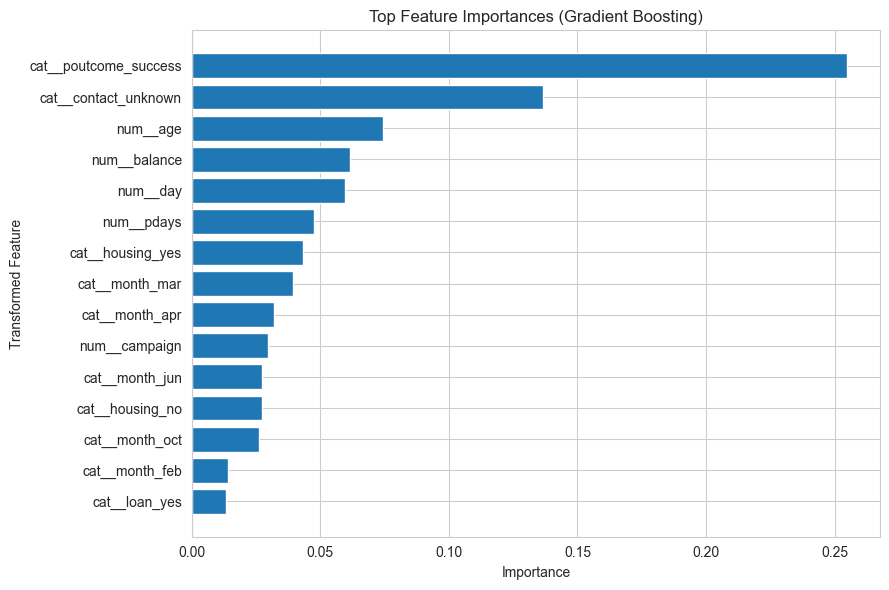


Segment check by marital:
    marital  customers  avg_predicted_score  actual_response_rate
2    single        661             0.526440              0.547655
0  divorced        265             0.469866              0.498113
1   married       1307             0.440771              0.431523

Segment check by education:
   education  customers  avg_predicted_score  actual_response_rate
3    unknown         83             0.530676              0.469880
2   tertiary        732             0.526338              0.546448
1  secondary       1119             0.447682              0.442359
0    primary        299             0.395643              0.414716

Segment check by job:
              job  customers  avg_predicted_score  actual_response_rate
8         student         63             0.745233              0.650794
5         retired        166             0.674822              0.692771
10     unemployed         78             0.537913              0.602564
11        unknown         16      

In [25]:
# Step 7 — Explainability: feature importance + basic fairness-oriented segment check
# This helps explain model behavior to business stakeholders and supports responsible AI discussion.

# Import numpy for numeric operations
import numpy as np

# Import pandas for tabular summaries
import pandas as pd

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Safety checks to ensure previous steps were run
if "gb_pipeline" not in globals() or "X_test" not in globals() or "y_test" not in globals() or "gb_proba" not in globals():
    raise ValueError("Run Steps 3 and 4 first so gb_pipeline, X_test, y_test, and gb_proba are available.")

# Access fitted preprocessor and fitted Gradient Boosting model from pipeline
preprocess_obj = gb_pipeline.named_steps["preprocess"]
gb_model = gb_pipeline.named_steps["model"]

# Get transformed feature names after one-hot encoding
feature_names = preprocess_obj.get_feature_names_out()

# Get model feature importances (importance per transformed column)
importances = gb_model.feature_importances_

# Build DataFrame for feature importance analysis
importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": importances,
    }
).sort_values("importance", ascending=False)

# Display top 20 most important transformed features
top_n = 20
print(f"Top {top_n} transformed features by importance:")
print(importance_df.head(top_n))

# Plot top 15 features for quick interpretation
plot_n = 15
top_plot_df = importance_df.head(plot_n).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(top_plot_df["feature"], top_plot_df["importance"])
plt.title("Top Feature Importances (Gradient Boosting)")
plt.xlabel("Importance")
plt.ylabel("Transformed Feature")
plt.tight_layout()
plt.show()

# Build test-set analysis table with original fields + probability + true label
analysis_df = X_test.copy()
analysis_df["true_label"] = y_test.values
analysis_df["score"] = gb_proba

# Basic segment-level probability check (not a full fairness audit)
# These are business-relevant segments often reviewed in retail banking.
segment_cols = ["marital", "education", "job"]
segment_cols = [col for col in segment_cols if col in analysis_df.columns]

for col in segment_cols:
    segment_summary = (
        analysis_df.groupby(col, as_index=False)
        .agg(
            customers=("score", "count"),
            avg_predicted_score=("score", "mean"),
            actual_response_rate=("true_label", "mean"),
        )
        .sort_values("avg_predicted_score", ascending=False)
    )

    print(f"\nSegment check by {col}:")
    print(segment_summary)

print("\nInterpretation guide:")
print("1) Use top feature drivers to explain why model ranks customers higher/lower.")
print("2) Use segment summaries to spot unusually high/low scoring groups.")
print("3) Large score gaps across groups should trigger deeper fairness/guardrail checks.")

In [26]:
# Step 8 — Fairness watchlist (simple guardrail-style monitoring)
# Goal: flag segments that may need manual review before campaign rollout.

# Import pandas for grouped summaries
import pandas as pd

# Import numpy for numeric logic
import numpy as np

# Safety check: ensure analysis dataframe exists from Step 7
if "analysis_df" not in globals():
    raise ValueError("Run Step 7 first so analysis_df is available.")

# Configuration thresholds for risk labeling
# min_group_size: groups smaller than this are unstable and can be noisy
min_group_size = 50

# gap thresholds between predicted score and actual response
# large absolute gap may indicate calibration/fairness concern in that segment
medium_gap_threshold = 0.08
high_gap_threshold = 0.15

# Choose segment columns to monitor
watch_cols = ["marital", "education", "job"]
watch_cols = [col for col in watch_cols if col in analysis_df.columns]

# Store watchlist outputs from all segment columns
all_watchlist_rows = []

# Evaluate each segmentation dimension independently
for col in watch_cols:
    # Build segment summary with group size, average predicted score, and actual response rate
    grp = (
        analysis_df.groupby(col, as_index=False)
        .agg(
            customers=("score", "count"),
            avg_predicted_score=("score", "mean"),
            actual_response_rate=("true_label", "mean"),
        )
    )

    # Compute absolute calibration gap by segment
    grp["abs_score_actual_gap"] = (grp["avg_predicted_score"] - grp["actual_response_rate"]).abs()

    # Create risk label with simple explainable rules
    risk_labels = []
    risk_reasons = []

    for _, row in grp.iterrows():
        reasons = []

        # Rule 1: low sample size increases uncertainty
        if row["customers"] < min_group_size:
            reasons.append("small_sample")

        # Rule 2: large score-vs-actual mismatch
        if row["abs_score_actual_gap"] >= high_gap_threshold:
            reasons.append("large_gap")
        elif row["abs_score_actual_gap"] >= medium_gap_threshold:
            reasons.append("medium_gap")

        # Map reasons to risk tier
        if "large_gap" in reasons or ("small_sample" in reasons and "medium_gap" in reasons):
            risk = "HIGH"
        elif "small_sample" in reasons or "medium_gap" in reasons:
            risk = "MEDIUM"
        else:
            risk = "LOW"

        # Save label and reason text
        risk_labels.append(risk)
        risk_reasons.append(",".join(reasons) if reasons else "none")

    # Attach risk outputs to this segment summary
    grp["risk_level"] = risk_labels
    grp["risk_reason"] = risk_reasons
    grp["segment_type"] = col

    # Reorder columns for readability
    grp = grp[
        [
            "segment_type",
            col,
            "customers",
            "avg_predicted_score",
            "actual_response_rate",
            "abs_score_actual_gap",
            "risk_level",
            "risk_reason",
        ]
    ]

    # Rename segment value column to a common label for concatenation
    grp = grp.rename(columns={col: "segment_value"})

    # Add this grouped watchlist to the combined list
    all_watchlist_rows.append(grp)

# Combine all segment watchlists into one table
watchlist_df = pd.concat(all_watchlist_rows, ignore_index=True)

# Sort: highest risk first, then largest gap first
risk_order = {"HIGH": 0, "MEDIUM": 1, "LOW": 2}
watchlist_df["risk_rank"] = watchlist_df["risk_level"].map(risk_order)
watchlist_df = watchlist_df.sort_values(["risk_rank", "abs_score_actual_gap"], ascending=[True, False]).drop(columns=["risk_rank"])

# Print full fairness watchlist table
print("Fairness watchlist (guardrail monitoring table):")
print(watchlist_df)

# Print only high-risk rows for quick review
high_risk_df = watchlist_df[watchlist_df["risk_level"] == "HIGH"]
print("\nHigh-risk segments requiring manual review:")
if high_risk_df.empty:
    print("No HIGH risk segments found with current thresholds.")
else:
    print(high_risk_df)

# Business interpretation note
print("\nInterpretation:")
print("Use this watchlist before campaign launch to prevent unstable or potentially unfair segment decisions.")
print("For Level 3, your guardrail agent can automatically block or escalate HIGH risk segments.")

Fairness watchlist (guardrail monitoring table):
   segment_type  segment_value  customers  avg_predicted_score  \
10          job      housemaid         48             0.447770   
15          job        student         63             0.745233   
18          job        unknown         16             0.536343   
17          job     unemployed         78             0.537913   
6     education        unknown         83             0.530676   
13          job  self-employed         94             0.473330   
14          job       services        196             0.387586   
0       marital       divorced        265             0.469866   
2       marital         single        661             0.526440   
5     education       tertiary        732             0.526338   
11          job     management        488             0.511260   
8           job    blue-collar        402             0.358655   
3     education        primary        299             0.395643   
9           job   entrepren

In [27]:
# Step 9 — Guardrail decision function (ALLOW / REVIEW / BLOCK)
# This converts fairness watchlist rules into actionable controls for AI offer delivery.

# Import pandas for table joins and transformations
import pandas as pd

# Safety check: ensure required outputs from previous steps are available
if "analysis_df" not in globals() or "watchlist_df" not in globals():
    raise ValueError("Run Steps 7 and 8 first so analysis_df and watchlist_df are available.")

# Copy analysis table to keep original data unchanged
guardrail_df = analysis_df.copy()

# Keep only key watchlist fields for joining
watch_cols = ["segment_type", "segment_value", "risk_level", "risk_reason"]
watch_lookup = watchlist_df[watch_cols].copy()

# Build risk lookups per segment type (job/marital/education)
job_risk = watch_lookup[watch_lookup["segment_type"] == "job"].rename(columns={"segment_value": "job"})
marital_risk = watch_lookup[watch_lookup["segment_type"] == "marital"].rename(columns={"segment_value": "marital"})
edu_risk = watch_lookup[watch_lookup["segment_type"] == "education"].rename(columns={"segment_value": "education"})

# Join job risk to each customer row
guardrail_df = guardrail_df.merge(
    job_risk[["job", "risk_level", "risk_reason"]],
    on="job",
    how="left",
    suffixes=("", "_job"),
)

# Rename merged risk fields for clarity
guardrail_df = guardrail_df.rename(
    columns={
        "risk_level": "job_risk_level",
        "risk_reason": "job_risk_reason",
    }
)

# Join marital risk to each customer row
guardrail_df = guardrail_df.merge(
    marital_risk[["marital", "risk_level", "risk_reason"]],
    on="marital",
    how="left",
    suffixes=("", "_marital"),
)

# Rename merged marital risk fields
guardrail_df = guardrail_df.rename(
    columns={
        "risk_level": "marital_risk_level",
        "risk_reason": "marital_risk_reason",
    }
)

# Join education risk to each customer row
guardrail_df = guardrail_df.merge(
    edu_risk[["education", "risk_level", "risk_reason"]],
    on="education",
    how="left",
    suffixes=("", "_education"),
)

# Rename merged education risk fields
guardrail_df = guardrail_df.rename(
    columns={
        "risk_level": "education_risk_level",
        "risk_reason": "education_risk_reason",
    }
)

# Fill missing risk levels with LOW (if segment was not present in watchlist)
for col in ["job_risk_level", "marital_risk_level", "education_risk_level"]:
    guardrail_df[col] = guardrail_df[col].fillna("LOW")

# Fill missing reasons with none
for col in ["job_risk_reason", "marital_risk_reason", "education_risk_reason"]:
    guardrail_df[col] = guardrail_df[col].fillna("none")

# Define helper map to compare risk levels numerically
risk_priority = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}

# Compute maximum segment risk for each customer
max_risk_value = guardrail_df[["job_risk_level", "marital_risk_level", "education_risk_level"]].apply(
    lambda row: max(risk_priority[v] for v in row),
    axis=1,
)

# Convert max numeric risk back to text label
inverse_risk_priority = {1: "LOW", 2: "MEDIUM", 3: "HIGH"}
guardrail_df["max_segment_risk"] = max_risk_value.map(inverse_risk_priority)

# Apply policy rules for AI offer actions
# Rule 1: BLOCK if any segment is HIGH risk (manual review required)
# Rule 2: REVIEW if max risk is MEDIUM or score is near decision boundary
# Rule 3: ALLOW if risk is LOW and score is comfortably above threshold
chosen_threshold = 0.40
review_band = 0.05

def decide_action(row):
    # Block high-risk segment combinations
    if row["max_segment_risk"] == "HIGH":
        return "BLOCK"
    # Review medium-risk or uncertain-score cases
    if row["max_segment_risk"] == "MEDIUM":
        return "REVIEW"
    if abs(row["score"] - chosen_threshold) <= review_band:
        return "REVIEW"
    # Allow confident low-risk cases
    if row["score"] > chosen_threshold:
        return "ALLOW"
    # Below threshold and low-risk means no action now
    return "REVIEW"

# Generate guardrail action per customer
guardrail_df["guardrail_action"] = guardrail_df.apply(decide_action, axis=1)

# Print action distribution for quick policy view
print("Guardrail action distribution:")
print(guardrail_df["guardrail_action"].value_counts())

# Show sample rows for demonstration
sample_cols = [
    "score",
    "true_label",
    "job",
    "marital",
    "education",
    "job_risk_level",
    "marital_risk_level",
    "education_risk_level",
    "max_segment_risk",
    "guardrail_action",
]

print("\nSample guardrail decisions:")
print(guardrail_df[sample_cols].head(15))

# Portfolio note for storytelling
print("\nThis table can feed your Level 3 email agent: only ALLOW rows go to auto-personalized offers.")
print("REVIEW and BLOCK rows should be escalated to compliance/manual checks.")

Guardrail action distribution:
guardrail_action
REVIEW    1337
ALLOW      848
BLOCK       48
Name: count, dtype: int64

Sample guardrail decisions:
       score  true_label           job   marital  education job_risk_level  \
0   0.338162           0    management   married   tertiary            LOW   
1   0.549002           1    technician    single  secondary            LOW   
2   0.770535           0        admin.   married  secondary            LOW   
3   0.168693           0    management    single  secondary            LOW   
4   0.255253           1   blue-collar   married  secondary            LOW   
5   0.182804           0  entrepreneur   married    primary            LOW   
6   0.441264           0        admin.   married    unknown            LOW   
7   0.386684           1        admin.   married  secondary            LOW   
8   0.583715           1       retired  divorced   tertiary            LOW   
9   0.295778           1    management   married  secondary            L

In [31]:
# Step 10 — Generate personalized offer email drafts for ALLOW cases only
# This simulates your Level 3 AI agent output after guardrail checks.

# Import pandas for working with generated email tables
import pandas as pd

# Safety check: ensure guardrail output exists
if "guardrail_df" not in globals():
    raise ValueError("Run Step 9 first so guardrail_df is available.")

# Keep only customers approved for automated outreach
allowed_df = guardrail_df[guardrail_df["guardrail_action"] == "ALLOW"].copy()

# If there are no ALLOW rows, stop with guidance
if allowed_df.empty:
    raise ValueError("No ALLOW customers found. Revisit threshold/risk rules before generating emails.")

# Simple function to assign product theme by profile (rule-based baseline)
def assign_offer_theme(row):
    # Offer theme for younger segment likely building savings habits
    if row.get("job", "") == "student" or row.get("age", 0) < 28:
        return "Starter Savings Plan"
    # Offer theme for experienced segment seeking stable returns
    if row.get("job", "") == "retired" or row.get("age", 0) >= 55:
        return "Secure Term Deposit Plan"
    # Offer theme for salaried working segment
    if row.get("job", "") in ["admin.", "technician", "management"]:
        return "Smart Monthly Savings Plan"
    # Default theme for general customers
    return "Personal Savings Growth Plan"

# Apply offer theme selection per approved customer
allowed_df["offer_theme"] = allowed_df.apply(assign_offer_theme, axis=1)

# Define function to create personalized email body with safe, neutral language
def generate_email_body(row):
    # Build a neutral greeting without sensitive trait references
    greeting = "Dear Valued Customer,"

    # Create main message focused on financial goals and product value
    body = (
        f"We are pleased to share an offer that may support your savings goals: "
        f"{row['offer_theme']}. "
        "This option is designed to help customers grow their balances with flexible terms and clear returns."
    )

    # Add transparent eligibility and support note
    support = (
        "If you would like details on expected returns, tenure options, and eligibility, "
        "our team will be happy to assist you."
    )

    # Add compliance-friendly closing statement
    closing = "Kind regards,\nRetail Banking Team"

    # Return complete email text
    return f"{greeting}\n\n{body}\n\n{support}\n\n{closing}"

# Generate email subject line based on assigned offer
allowed_df["email_subject"] = allowed_df["offer_theme"].apply(
    lambda x: f"A savings offer for your financial goals: {x}"
)

# Generate full email body
allowed_df["email_body"] = allowed_df.apply(generate_email_body, axis=1)

# Select columns for demonstration output
email_cols = [
    "score",
    "offer_theme",
    "email_subject",
    "email_body",
]

# Create final email draft table
email_drafts_df = allowed_df[email_cols].copy()

# Show count of generated drafts
print("Total personalized drafts generated (ALLOW only):", len(email_drafts_df))

# Show first 5 drafts for review
print("\nSample email drafts:")
print(email_drafts_df.head(5))

# Optional: export drafts for portfolio demonstration
# email_drafts_df.to_csv("personalized_offer_drafts.csv", index=False)

# Portfolio note
print("\nStep 10 complete: Offer drafts generated only for policy-approved customers.")
print("This demonstrates AI generation controlled by a guardrail layer.")

Total personalized drafts generated (ALLOW only): 848

Sample email drafts:
       score                 offer_theme  \
1   0.549002  Smart Monthly Savings Plan   
2   0.770535  Smart Monthly Savings Plan   
8   0.583715    Secure Term Deposit Plan   
12  0.949080    Secure Term Deposit Plan   
16  0.626069        Starter Savings Plan   

                                        email_subject  \
1   A savings offer for your financial goals: Smar...   
2   A savings offer for your financial goals: Smar...   
8   A savings offer for your financial goals: Secu...   
12  A savings offer for your financial goals: Secu...   
16  A savings offer for your financial goals: Star...   

                                           email_body  
1   Dear Valued Customer,\n\nWe are pleased to sha...  
2   Dear Valued Customer,\n\nWe are pleased to sha...  
8   Dear Valued Customer,\n\nWe are pleased to sha...  
12  Dear Valued Customer,\n\nWe are pleased to sha...  
16  Dear Valued Customer,\n\nWe are 

In [32]:
# Step 11 — Mock LLM email generation + text guardrail checker (no API key needed)
# This simulates a real GenAI workflow while keeping your notebook fully runnable offline.

# Import pandas for tabular output management
import pandas as pd

# Import random to create slight variation in mock LLM outputs
import random

# Safety checks to ensure previous steps are complete
if "allowed_df" not in globals() and "email_drafts_df" not in globals():
    raise ValueError("Run Step 10 first so approved customer rows are available.")

# Rebuild approved input table from Step 10 source if available
if "allowed_df" in globals():
    llm_input_df = allowed_df.copy()
else:
    # Fallback if only email draft table exists
    llm_input_df = guardrail_df[guardrail_df["guardrail_action"] == "ALLOW"].copy()

# Limit generation size for demo readability (increase later for full runs)
max_drafts = 20
llm_input_df = llm_input_df.head(max_drafts).copy()

# Prompt template that represents what would be sent to a real LLM
# We deliberately avoid sensitive attributes and use neutral financial language.
def build_prompt(row):
    return (
        "You are a retail banking assistant. "
        "Write a professional, concise offer email in 90-120 words. "
        "Do not mention sensitive attributes. "
        "Use neutral and compliant tone. "
        f"Offer theme: {row.get('offer_theme', 'Personal Savings Growth Plan')}. "
        "Goal: encourage customer to learn more about eligible savings options."
    )

# Mock LLM generator to simulate varied but policy-friendly outputs
# In production, replace this with a real LLM API call.
def mock_llm_generate(prompt_text, offer_theme):
    # Predefined opening options for natural variation
    openings = [
        "Dear Valued Customer,",
        "Hello,",
        "Greetings from our Retail Banking Team,",
    ]

    # Predefined value propositions to mimic model creativity
    value_lines = [
        "This plan offers clear returns with transparent terms.",
        "It is designed to support steady savings growth based on your goals.",
        "You can review flexible tenure and contribution options with our advisors.",
    ]

    # Randomly choose one opening and two value lines for variation
    opening = random.choice(openings)
    selected_values = random.sample(value_lines, 2)

    # Compose mock generated email body
    generated = (
        f"{opening}\n\n"
        f"We would like to introduce our {offer_theme}. "
        f"{selected_values[0]} {selected_values[1]} "
        "If you are interested, our team can share eligibility details and expected return scenarios.\n\n"
        "Kind regards,\nRetail Banking Team"
    )

    return generated

# Text guardrail checker for generated content
# Flags sensitive words and risky claims to simulate compliance review.
def text_guardrail_check(email_text):
    # Terms to avoid in outbound marketing text (example list)
    blocked_terms = [
        "religion", "race", "ethnicity", "nationality", "gender", "disability",
        "guaranteed profit", "risk-free return", "no risk",
    ]

    # Convert to lowercase for case-insensitive matching
    text_lower = str(email_text).lower()

    # Detect blocked terms present in generated text
    hits = [term for term in blocked_terms if term in text_lower]

    # Decision logic
    if len(hits) > 0:
        return "REVIEW", ", ".join(hits)

    # If no blocked terms found, approve draft
    return "ALLOW", "none"

# Generate mock LLM outputs and run guardrail checks
rows = []
for _, row in llm_input_df.iterrows():
    # Build synthetic prompt
    prompt_text = build_prompt(row)

    # Create mock generated email
    generated_email = mock_llm_generate(prompt_text, row.get("offer_theme", "Personal Savings Growth Plan"))

    # Run text-level guardrail check
    text_action, text_reason = text_guardrail_check(generated_email)

    # Combine with earlier policy decision (already ALLOW from Step 10 source)
    # Final action: if text checker says REVIEW, escalate.
    final_action = "REVIEW" if text_action == "REVIEW" else "ALLOW"

    # Save output row
    rows.append(
        {
            "score": row.get("score", None),
            "offer_theme": row.get("offer_theme", "Personal Savings Growth Plan"),
            "llm_prompt": prompt_text,
            "llm_generated_email": generated_email,
            "text_guardrail_action": text_action,
            "text_guardrail_reason": text_reason,
            "final_action": final_action,
        }
    )

# Build final DataFrame for Level 3 demonstration
llm_email_drafts_df = pd.DataFrame(rows)

# Display action counts for quick governance summary
print("Mock LLM generation complete.")
print("Final action distribution:")
print(llm_email_drafts_df["final_action"].value_counts())

# Show sample outputs
print("\nSample generated emails (first 3):")
print(llm_email_drafts_df[["offer_theme", "llm_generated_email", "final_action"]].head(3))

# Optional export for portfolio artifacts
# llm_email_drafts_df.to_csv("mock_llm_offer_drafts_with_guardrails.csv", index=False)

print("\nStep 11 complete: you now have a mock GenAI + guardrail pipeline.")
print("When ready, replace mock_llm_generate() with a real LLM API call.")

Mock LLM generation complete.
Final action distribution:
final_action
ALLOW    20
Name: count, dtype: int64

Sample generated emails (first 3):
                  offer_theme  \
0  Smart Monthly Savings Plan   
1  Smart Monthly Savings Plan   
2    Secure Term Deposit Plan   

                                 llm_generated_email final_action  
0  Greetings from our Retail Banking Team,\n\nWe ...        ALLOW  
1  Hello,\n\nWe would like to introduce our Smart...        ALLOW  
2  Dear Valued Customer,\n\nWe would like to intr...        ALLOW  

Step 11 complete: you now have a mock GenAI + guardrail pipeline.
When ready, replace mock_llm_generate() with a real LLM API call.


In [33]:
# Step 12 — One-call end-to-end demo for interviews and portfolio walkthroughs
# run_end_to_end_demo() rebuilds the pipeline from bank.csv so you can rerun everything cleanly.

# Import standard library typing for clear return type documentation
from typing import Dict, Any

# Import numpy for numeric operations inside the demo pipeline
import numpy as np

# Import random for reproducible mock LLM variation when seeded
import random

# Import pandas for data loading and tabular results
import pandas as pd

# Import sklearn split utility for train/test separation
from sklearn.model_selection import train_test_split

# Import sklearn preprocessing and composition utilities
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Import sklearn pipeline to chain preprocessing + model
from sklearn.pipeline import Pipeline

# Import sklearn metrics for quick evaluation summary
from sklearn.metrics import roc_auc_score

# Import gradient boosting classifier used as primary model in this project
from sklearn.ensemble import GradientBoostingClassifier


def run_end_to_end_demo(
    csv_path: str = "bank.csv",
    random_state: int = 42,
    max_llm_drafts: int = 10,
) -> Dict[str, Any]:
    """Train GB model, then run fairness watchlist, policy guardrails, and mock LLM drafts (no API keys)."""

    # Load CSV using semicolon first (some dataset variants use ';')
    df_local = pd.read_csv(csv_path, sep=";")

    # If parsing failed (single column), reload with comma separator
    if df_local.shape[1] == 1:
        df_local = pd.read_csv(csv_path, sep=",")

    # Detect target column name for this dataset version
    if "y" in df_local.columns:
        target_col_local = "y"
    elif "deposit" in df_local.columns:
        target_col_local = "deposit"
    else:
        raise ValueError("Expected target column 'y' or 'deposit' not found.")

    # Build feature list excluding target and leakage column duration
    feature_cols_local = [c for c in df_local.columns if c != target_col_local and c != "duration"]

    # Feature matrix and binary labels
    X_local = df_local[feature_cols_local].copy()
    y_local = (
        df_local[target_col_local]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"yes": 1, "no": 0})
    )

    # Stratified split for stable evaluation
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_local,
        y_local,
        test_size=0.2,
        random_state=random_state,
        stratify=y_local,
    )

    # Numeric vs categorical columns from training features
    num_feats = X_tr.select_dtypes(include=["number"]).columns.tolist()
    cat_feats = [c for c in X_tr.columns if c not in num_feats]

    # Preprocessor: pass numeric through, one-hot encode categoricals
    pre = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_feats),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_feats),
        ],
    )

    # Gradient boosting pipeline (matches main notebook story)
    gb_pipe = Pipeline(
        steps=[
            ("preprocess", pre),
            ("model", GradientBoostingClassifier(random_state=random_state)),
        ]
    )

    # Fit model on training data only
    gb_pipe.fit(X_tr, y_tr)

    # Predict probabilities on test set for positive class
    proba = gb_pipe.predict_proba(X_te)[:, 1]

    # ROC-AUC summary for portfolio talking point
    auc = float(roc_auc_score(y_te, proba))

    # Fixed business threshold chosen earlier in notebook (Step 5)
    thr = 0.40

    # Top 10% lift simulation on test set
    eval_tbl = pd.DataFrame({"y": y_te.values, "p": proba}).sort_values("p", ascending=False)
    baseline = float(eval_tbl["y"].mean())
    n_top = int(np.ceil(len(eval_tbl) * 0.10))
    top_rate = float(eval_tbl.head(n_top)["y"].mean())
    lift_10 = float(top_rate / baseline) if baseline > 0 else float("nan")

    # Simple mock email preview for highest propensity customer on test set
    best_p = float(eval_tbl["p"].iloc[0])
    mock_email = (
        "Dear Valued Customer,\n\n"
        "We invite you to explore our savings options aligned with your financial goals. "
        "Our team can share eligibility, tenure choices, and expected return scenarios.\n\n"
        "Kind regards,\nRetail Banking Team"
    )

    # Build analysis table used by fairness watchlist and guardrails
    analysis_df_local = X_te.copy()
    analysis_df_local["true_label"] = y_te.values
    analysis_df_local["score"] = proba

    # Fairness watchlist thresholds (same idea as Step 8)
    min_group_size = 50
    medium_gap_threshold = 0.08
    high_gap_threshold = 0.15
    watch_cols = ["marital", "education", "job"]
    watch_cols = [c for c in watch_cols if c in analysis_df_local.columns]
    all_watchlist_rows = []

    for col in watch_cols:
        grp = (
            analysis_df_local.groupby(col, as_index=False)
            .agg(
                customers=("score", "count"),
                avg_predicted_score=("score", "mean"),
                actual_response_rate=("true_label", "mean"),
            )
        )
        grp["abs_score_actual_gap"] = (grp["avg_predicted_score"] - grp["actual_response_rate"]).abs()
        risk_labels = []
        risk_reasons = []
        for _, row in grp.iterrows():
            reasons = []
            if row["customers"] < min_group_size:
                reasons.append("small_sample")
            if row["abs_score_actual_gap"] >= high_gap_threshold:
                reasons.append("large_gap")
            elif row["abs_score_actual_gap"] >= medium_gap_threshold:
                reasons.append("medium_gap")
            if "large_gap" in reasons or ("small_sample" in reasons and "medium_gap" in reasons):
                risk = "HIGH"
            elif "small_sample" in reasons or "medium_gap" in reasons:
                risk = "MEDIUM"
            else:
                risk = "LOW"
            risk_labels.append(risk)
            risk_reasons.append(",".join(reasons) if reasons else "none")
        grp["risk_level"] = risk_labels
        grp["risk_reason"] = risk_reasons
        grp["segment_type"] = col
        grp = grp[
            [
                "segment_type",
                col,
                "customers",
                "avg_predicted_score",
                "actual_response_rate",
                "abs_score_actual_gap",
                "risk_level",
                "risk_reason",
            ]
        ]
        grp = grp.rename(columns={col: "segment_value"})
        all_watchlist_rows.append(grp)

    watchlist_df_local = pd.concat(all_watchlist_rows, ignore_index=True)
    risk_order = {"HIGH": 0, "MEDIUM": 1, "LOW": 2}
    watchlist_df_local["risk_rank"] = watchlist_df_local["risk_level"].map(risk_order)
    watchlist_df_local = watchlist_df_local.sort_values(
        ["risk_rank", "abs_score_actual_gap"], ascending=[True, False]
    ).drop(columns=["risk_rank"])
    high_risk_df_local = watchlist_df_local[watchlist_df_local["risk_level"] == "HIGH"].copy()

    # Policy guardrail joins (same idea as Step 9)
    guardrail_df_local = analysis_df_local.copy()
    watch_lookup = watchlist_df_local[["segment_type", "segment_value", "risk_level", "risk_reason"]].copy()
    job_risk = watch_lookup[watch_lookup["segment_type"] == "job"].rename(columns={"segment_value": "job"})
    marital_risk = watch_lookup[watch_lookup["segment_type"] == "marital"].rename(columns={"segment_value": "marital"})
    edu_risk = watch_lookup[watch_lookup["segment_type"] == "education"].rename(columns={"segment_value": "education"})

    guardrail_df_local = guardrail_df_local.merge(
        job_risk[["job", "risk_level", "risk_reason"]], on="job", how="left", suffixes=("", "_job")
    )
    guardrail_df_local = guardrail_df_local.rename(
        columns={"risk_level": "job_risk_level", "risk_reason": "job_risk_reason"}
    )
    guardrail_df_local = guardrail_df_local.merge(
        marital_risk[["marital", "risk_level", "risk_reason"]], on="marital", how="left", suffixes=("", "_marital")
    )
    guardrail_df_local = guardrail_df_local.rename(
        columns={"risk_level": "marital_risk_level", "risk_reason": "marital_risk_reason"}
    )
    guardrail_df_local = guardrail_df_local.merge(
        edu_risk[["education", "risk_level", "risk_reason"]], on="education", how="left", suffixes=("", "_education")
    )
    guardrail_df_local = guardrail_df_local.rename(
        columns={"risk_level": "education_risk_level", "risk_reason": "education_risk_reason"}
    )
    for col in ["job_risk_level", "marital_risk_level", "education_risk_level"]:
        guardrail_df_local[col] = guardrail_df_local[col].fillna("LOW")
    for col in ["job_risk_reason", "marital_risk_reason", "education_risk_reason"]:
        guardrail_df_local[col] = guardrail_df_local[col].fillna("none")

    risk_priority = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    max_risk_value = guardrail_df_local[["job_risk_level", "marital_risk_level", "education_risk_level"]].apply(
        lambda row: max(risk_priority[v] for v in row), axis=1
    )
    inverse_risk_priority = {1: "LOW", 2: "MEDIUM", 3: "HIGH"}
    guardrail_df_local["max_segment_risk"] = max_risk_value.map(inverse_risk_priority)

    review_band = 0.05

    def decide_action(row):
        if row["max_segment_risk"] == "HIGH":
            return "BLOCK"
        if row["max_segment_risk"] == "MEDIUM":
            return "REVIEW"
        if abs(row["score"] - thr) <= review_band:
            return "REVIEW"
        if row["score"] > thr:
            return "ALLOW"
        return "REVIEW"

    guardrail_df_local["guardrail_action"] = guardrail_df_local.apply(decide_action, axis=1)
    action_counts_local = guardrail_df_local["guardrail_action"].value_counts().to_dict()

    sample_cols = [
        "score",
        "true_label",
        "job",
        "marital",
        "education",
        "job_risk_level",
        "marital_risk_level",
        "education_risk_level",
        "max_segment_risk",
        "guardrail_action",
    ]
    guardrail_sample_df_local = guardrail_df_local[sample_cols].head(12).copy()

    # Offer theme assignment for approved customers only (same idea as Step 10)
    def assign_offer_theme(row):
        if row.get("job", "") == "student" or row.get("age", 0) < 28:
            return "Starter Savings Plan"
        if row.get("job", "") == "retired" or row.get("age", 0) >= 55:
            return "Secure Term Deposit Plan"
        if row.get("job", "") in ["admin.", "technician", "management"]:
            return "Smart Monthly Savings Plan"
        return "Personal Savings Growth Plan"

    allowed_local = guardrail_df_local[guardrail_df_local["guardrail_action"] == "ALLOW"].copy()
    allowed_local["offer_theme"] = allowed_local.apply(assign_offer_theme, axis=1)

    # Mock LLM + text guardrail (same idea as Step 11)
    blocked_terms = [
        "religion",
        "race",
        "ethnicity",
        "nationality",
        "gender",
        "disability",
        "guaranteed profit",
        "risk-free return",
        "no risk",
    ]
    openings = [
        "Dear Valued Customer,",
        "Hello,",
        "Greetings from our Retail Banking Team,",
    ]
    value_lines = [
        "This plan offers clear returns with transparent terms.",
        "It is designed to support steady savings growth based on your goals.",
        "You can review flexible tenure and contribution options with our advisors.",
    ]

    random.seed(random_state)
    llm_rows = []
    for _, row in allowed_local.head(max_llm_drafts).iterrows():
        offer_theme = row.get("offer_theme", "Personal Savings Growth Plan")
        prompt_text = (
            "You are a retail banking assistant. "
            "Write a professional, concise offer email in 90-120 words. "
            "Do not mention sensitive attributes. "
            f"Offer theme: {offer_theme}."
        )
        opening = random.choice(openings)
        selected_values = random.sample(value_lines, 2)
        generated_email = (
            f"{opening}\n\n"
            f"We would like to introduce our {offer_theme}. "
            f"{selected_values[0]} {selected_values[1]} "
            "If you are interested, our team can share eligibility details and expected return scenarios.\n\n"
            "Kind regards,\nRetail Banking Team"
        )
        text_lower = str(generated_email).lower()
        hits = [term for term in blocked_terms if term in text_lower]
        text_action = "REVIEW" if len(hits) > 0 else "ALLOW"
        text_reason = ", ".join(hits) if hits else "none"
        final_action = "REVIEW" if text_action == "REVIEW" else "ALLOW"
        llm_rows.append(
            {
                "score": row.get("score"),
                "offer_theme": offer_theme,
                "llm_prompt": prompt_text,
                "llm_generated_email": generated_email,
                "text_guardrail_action": text_action,
                "text_guardrail_reason": text_reason,
                "final_action": final_action,
            }
        )
    mock_llm_drafts_df_local = pd.DataFrame(llm_rows)

    return {
        "rows": int(len(df_local)),
        "test_rows": int(len(X_te)),
        "roc_auc": round(auc, 4),
        "threshold": thr,
        "lift_top10_vs_random": round(lift_10, 3),
        "baseline_response_rate_test": round(baseline, 4),
        "top10_response_rate_test": round(top_rate, 4),
        "demo_mock_llm_email_preview": mock_email,
        "highest_test_probability": round(best_p, 4),
        "watchlist_df": watchlist_df_local,
        "high_risk_segments_df": high_risk_df_local,
        "guardrail_action_counts": action_counts_local,
        "guardrail_sample_df": guardrail_sample_df_local,
        "mock_llm_drafts_df": mock_llm_drafts_df_local,
    }


def print_demo_summary(summary: Dict[str, Any]) -> None:
    """Print scalar metrics and preview DataFrames without flooding the notebook output."""
    print("End-to-end demo summary:")
    for demo_key, demo_value in summary.items():
        if isinstance(demo_value, pd.DataFrame):
            print(f"\n{demo_key} (shape {demo_value.shape}):")
            print(demo_value.to_string(max_rows=10))
        else:
            print(f"  {demo_key}: {demo_value}")
    print("\nTip: run print_demo_summary(run_end_to_end_demo(max_llm_drafts=5)) after a kernel restart.")


# Run demo once when this cell executes
demo_summary = run_end_to_end_demo()
print_demo_summary(demo_summary)

End-to-end demo summary:
  rows: 11162
  test_rows: 2233
  roc_auc: 0.7935
  threshold: 0.4
  lift_top10_vs_random: 1.941
  baseline_response_rate_test: 0.4738
  top10_response_rate_test: 0.9196
  demo_mock_llm_email_preview: Dear Valued Customer,

We invite you to explore our savings options aligned with your financial goals. Our team can share eligibility, tenure choices, and expected return scenarios.

Kind regards,
Retail Banking Team
  highest_test_probability: 0.9782

Tip: call run_end_to_end_demo() anytime after restarting the kernel for a clean walkthrough.
